# ASR Final Project

STUDENT 1: 
ID: 312169527
NAME: Ariel Keslassy

STUDENT 2: 
ID: 318335445
NAME: Kai Cheifetz

# CWD

In [48]:
# ===== Cell 1: Setup =====
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
# If the notebook is opened from notebooks/, move one directory up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = C:\Users\kaiia\OneDrive\Desktop\asr_final_paper


# Auto-reload

In [49]:
# ===== Cell 2: Autoreload (important for interactive .py sync) =====
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Imports

In [50]:
# ===== Cell 3: Imports =====
from asr_project.config import ProjectConfig
from asr_project.commonvoice import load_commonvoice_test_rows
from asr_project.transcribe import WhisperHebrewTranscriber, transcribe_benchmark_to_tsv
from asr_project.evaluate import evaluate_transcriptions_tsv
from asr_project.normalize_he import reference_normalize, transcription_normalize
from asr_project.stage_c_iterative import build_default_stage_c_steps, run_stage_c_iterative
from asr_project.noise_augment import (
    NoiseProfile, profile_from_modulo, create_noisy_benchmark
)
from sequence_alignment import align_sequences, EditWeights

import pandas as pd


# Whisper DEMO RUN

In [51]:
# import faster_whisper
# model = faster_whisper.WhisperModel('ivrit-ai/whisper-large-v3-turbo-ct2')

# segs, _ = model.transcribe('media-file', language='he')

# texts = [s.text for s in segs]

# transcribed_text = ' '.join(texts)
# print(f'Transcribed text: {transcribed_text}')

# (A) Basic Transcription

In [52]:
# ===== Part A: Config =====
cfg = ProjectConfig.default(PROJECT_ROOT)
cfg.ensure_dirs()

# If you have a GPU, you can switch device/compute type:
# cfg.device = "cuda"
# cfg.compute_type = "float16"

print(cfg)


ProjectConfig(project_root=WindowsPath('C:/Users/kaiia/OneDrive/Desktop/asr_final_paper'), commonvoice_root=WindowsPath('C:/Users/kaiia/OneDrive/Desktop/asr_final_paper/data/commonvoice_he'), musan_root=WindowsPath('C:/Users/kaiia/OneDrive/Desktop/asr_final_paper/data/musan'), outputs_dir=WindowsPath('C:/Users/kaiia/OneDrive/Desktop/asr_final_paper/data/outputs'), noisy_dir=WindowsPath('C:/Users/kaiia/OneDrive/Desktop/asr_final_paper/data/noisy_benchmark'), model_name_or_path='ivrit-ai/whisper-large-v3-turbo-ct2', language='he', device='cpu', compute_type='int8')


In [53]:
# ===== Part A: Load CommonVoice test rows =====
rows = load_commonvoice_test_rows(cfg.commonvoice_test_tsv)
len(rows), rows[0]

(910,
 CommonVoiceRow(path='common_voice_he_42922381.mp3', sentence='אלא מבטאים גם הישגים בתחומי הספורט והאמנות', raw={'client_id': '1940441e971196db08e0d5940f8a7a472a975e7a1fbe4cfe73604213b2303914ad7214353ca908e30951bcd89a49b9921350a5803cfbf2c91290d6da0bb1cda5', 'path': 'common_voice_he_42922381.mp3', 'sentence_id': '1517839a4d0e2476c0b9520ef5516e611199b01d1def5d0eb408046631ac0371', 'sentence': 'אלא מבטאים גם הישגים בתחומי הספורט והאמנות', 'sentence_domain': '', 'up_votes': '2', 'down_votes': '0', 'age': '', 'gender': '', 'accents': 'ישראלי', 'variant': '', 'locale': 'he', 'segment': ''}))

In [54]:
# ===== Part A: Build transcriber =====
transcriber = WhisperHebrewTranscriber(
    model_name_or_path=cfg.model_name_or_path,
    device=cfg.device,
    compute_type=cfg.compute_type,
    language=cfg.language,
)

In [55]:
# ===== Part A: Run transcription (long run) =====
# uncomment to generate the output
# part_a_tsv = cfg.outputs_dir / "part_a_transcriptions.tsv"
#
# transcribe_benchmark_to_tsv(
#     rows=rows,
#     clips_dir=cfg.commonvoice_clips_dir,
#     output_tsv=part_a_tsv,
#     transcriber=transcriber,
#     resume=True,
# )
#
# print(part_a_tsv)


In [56]:
part_a_tsv = cfg.outputs_dir / "part_a_transcriptions.tsv"
print(part_a_tsv)


C:\Users\kaiia\OneDrive\Desktop\asr_final_paper\data\outputs\part_a_transcriptions.tsv


In [57]:
# ===== Part A: Quick peek =====
pd.read_csv(part_a_tsv, sep="\t", encoding="utf-8").head()

,Filename,Reference Text,Transcribed Text
0,common_voice_he_42922381,אלא מבטאים גם הישגים בתחומי הספורט והאמנות,אלה מבטאים גם הישגים בתחומי הספורט והאומנות.
1,common_voice_he_41896622,יום הזיכרון הוא יום של משפחת השכול כולה,יום הזיכרון הוא יום של משפחת השכול כולה.
2,common_voice_he_42358470,והם נמצאים במקום הזה לא בהתלהבות ולא בשמחה,והם נמצאים במקום הזה לא בהתלהבות ולא בשמחה.
3,common_voice_he_43313168,אז לצערי אנחנו לא יכולים לעשות הרבה,אז לצערי אנחנו לא יכולים לעשות הרבה.
4,common_voice_he_40977318,"העיר הפתוחה, אז, לפני כשנתיים ומשהו","העיר הפתוחה, אז, לפני כשנתיים ומשהו."


# (B) Evaluation without normalization (baseline)

# ===== Part B: Evaluate without normalization (baseline measurement) =====


In [58]:
part_b_metrics_tsv = cfg.outputs_dir / "part_b_metrics.tsv"
part_b_alignment_log_tsv = cfg.outputs_dir / "part_b_alignment_log.tsv"
part_b_errors_tsv = cfg.outputs_dir / "part_b_frequent_errors.tsv"

# uncomment to generate the output
# metrics_df_b, total_stats_b = evaluate_transcriptions_tsv(
#     transcriptions_tsv=part_a_tsv,
#     output_metrics_tsv=part_b_metrics_tsv,
#     output_alignment_log_tsv=part_b_alignment_log_tsv,
#     output_frequent_errors_tsv=part_b_errors_tsv,
#     reference_normalize=None,
#     transcription_normalize=None,
#     frequent_errors_min_count=2,
# )

metrics_df_b = pd.read_csv(part_b_metrics_tsv, sep="\t", encoding="utf-8")
metrics_df_b.tail()


,Filename,N_gt,N_asr,#M,#S,#I,#D,WER,Recall,Precision,F1-Score
906,common_voice_he_43539846,6,6,5,1,0,0,0.166667,0.833333,0.833333,0.833333
907,common_voice_he_43539848,6,6,5,1,0,0,0.166667,0.833333,0.833333,0.833333
908,common_voice_he_43539852,13,13,12,1,0,0,0.076923,0.923077,0.923077,0.923077
909,common_voice_he_43539859,7,7,7,0,0,0,0.000000,1.000000,1.000000,1.000000
910,TOTAL,6768,6793,4489,2190,114,89,0.353576,0.663268,0.660827,0.662046


In [59]:
# ===== Part B: TOTAL row =====
metrics_df_b[metrics_df_b["Filename"] == "TOTAL"]

,Filename,N_gt,N_asr,#M,#S,#I,#D,WER,Recall,Precision,F1-Score
910,TOTAL,6768,6793,4489,2190,114,89,0.353576,0.663268,0.660827,0.662046


In [60]:
# ===== Part B: Frequent errors preview =====
pd.read_csv(part_b_errors_tsv, sep="\t", encoding="utf-8").head(30)

,RefWord,HypWord,Count
0,אֶת,את,12
1,לֹא,לא,10
2,היתה,הייתה,9
3,הִיא,היא,7
4,זֶה,זה,6
5,שֶׁל,של,6
6,הזה,הזה.,6
7,NaN,אי,6
8,ירושלים,ירושלים.,6
9,מָה,מה,5


# (C) Iterative normalization

# ===== Part C: Evaluate with normalization =====


In [61]:
# ===== Part C: run iterative normalization =====
part_a_tsv = cfg.outputs_dir / "part_a_transcriptions.tsv"

part_c_steps = build_default_stage_c_steps()
part_c_summary_tsv = cfg.outputs_dir / "part_c_iterative_summary.tsv"
part_c_report_txt = cfg.outputs_dir / "part_c_iterative_report.txt"

# uncomment to generate the output
# summary_df_c, part_c_top_errors = run_stage_c_iterative(
#     transcriptions_tsv=part_a_tsv,
#     outputs_dir=cfg.outputs_dir,
#     steps=part_c_steps,
#     frequent_errors_min_count=2,
#     top_errors_eval=10,
#     top_errors_report=5,
#     summary_tsv_path=part_c_summary_tsv,
#     report_txt_path=part_c_report_txt,
# )

summary_df_c = pd.read_csv(part_c_summary_tsv, sep="\t", encoding="utf-8")
part_c_top_errors = {}
for step_idx, stage_name in enumerate(summary_df_c["Stage"], start=1):
    top_path = cfg.outputs_dir / f"part_c_top10_errors_stage{step_idx}.tsv"
    if top_path.exists():
        part_c_top_errors[stage_name] = pd.read_csv(top_path, sep="\t", encoding="utf-8")
    else:
        part_c_top_errors[stage_name] = pd.DataFrame(
            columns=["RefWord", "HypWord", "Count", "ErrorPair"]
        )

summary_df_c


,Stage,Description,Notes,WER,Recall,Precision,F1-Score,MetricsTSV,TopErrorsTSV
0,C_stage1_diacritics_only,Diacritics removal only,NaN,0.232713,0.784279,0.781393,0.782833,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...
1,C_stage2_plus_punctuation,Diacritics + punctuation normalization,NaN,0.114244,0.903469,0.898825,0.901141,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...
2,C_stage3_plus_hyphen,Diacritics + punctuation + hyphen normalization,NaN,0.084402,0.919534,0.924249,0.921885,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...
3,C_stage4_complete_normalization,Complete normalization + spelling equivalence map,NaN,0.080466,0.923469,0.928205,0.925831,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...
4,C_stage5_plus_num2words,Complete normalization + num2words digit-to-wo...,Known limitation: num2words may still choose t...,0.069388,0.934840,0.935249,0.935044,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...


In [62]:
# ===== Part C: add baseline row + compare =====
total_b = metrics_df_b[metrics_df_b["Filename"] == "TOTAL"].iloc[0]
baseline_row = pd.DataFrame([{
    "Stage": "B_baseline_no_normalization",
    "Description": "No normalization",
    "WER": float(total_b["WER"]),
    "Recall": float(total_b["Recall"]),
    "Precision": float(total_b["Precision"]),
    "F1-Score": float(total_b["F1-Score"]),
}])

part_c_notebook_summary = pd.concat([baseline_row, summary_df_c], ignore_index=True)
part_c_notebook_summary


,Stage,Description,WER,Recall,Precision,F1-Score,Notes,MetricsTSV,TopErrorsTSV
0,B_baseline_no_normalization,No normalization,0.353576,0.663268,0.660827,0.662046,NaN,NaN,NaN
1,C_stage1_diacritics_only,Diacritics removal only,0.232713,0.784279,0.781393,0.782833,NaN,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...
2,C_stage2_plus_punctuation,Diacritics + punctuation normalization,0.114244,0.903469,0.898825,0.901141,NaN,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...
3,C_stage3_plus_hyphen,Diacritics + punctuation + hyphen normalization,0.084402,0.919534,0.924249,0.921885,NaN,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...
4,C_stage4_complete_normalization,Complete normalization + spelling equivalence map,0.080466,0.923469,0.928205,0.925831,NaN,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...
5,C_stage5_plus_num2words,Complete normalization + num2words digit-to-wo...,0.069388,0.934840,0.935249,0.935044,Known limitation: num2words may still choose t...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...,C:\Users\kaiia\OneDrive\Desktop\asr_final_pape...


In [63]:
# ===== Part C: top-5 frequent errors per stage + TXT report =====
for stage_name, errors_df in part_c_top_errors.items():
    print(f"\n{stage_name} - top 5 frequent errors:")
    print(errors_df.head(5).to_string(index=False))

print(f"\nSaved iterative report to: {part_c_report_txt}")
print(part_c_report_txt.read_text(encoding="utf-8"))



C_stage1_diacritics_only - top 5 frequent errors:
RefWord  HypWord  Count           ErrorPair
   היתה    הייתה     11       היתה -> הייתה
    הזה     הזה.      6         הזה -> הזה.
    NaN       אי      6         <eps> -> אי
ירושלים ירושלים.      6 ירושלים -> ירושלים.
   הזאת    הזאת.      5       הזאת -> הזאת.

C_stage2_plus_punctuation - top 5 frequent errors:
RefWord HypWord  Count       ErrorPair
      -     NaN     14      - -> <eps>
   היתה   הייתה     11   היתה -> הייתה
    NaN      אי      7     <eps> -> אי
אי-אפשר    אפשר      6 אי-אפשר -> אפשר
    NaN       -      5      <eps> -> -

C_stage3_plus_hyphen - top 5 frequent errors:
RefWord HypWord  Count       ErrorPair
   היתה   הייתה     11   היתה -> הייתה
 אלפיים     NaN      5 אלפיים -> <eps>
    אלף     000      5      אלף -> 000
    אלף     NaN      4    אלף -> <eps>
  עשרים     NaN      4  עשרים -> <eps>

C_stage4_complete_normalization - top 5 frequent errors:
RefWord HypWord  Count       ErrorPair
 אלפיים     NaN      

# (D) Noise augmentation

Part D inference is intentionally **not** run through the notebook kernel because it is long-running and easier to resume safely from terminal commands.

Run from terminal:
`python3 run_part_d.py --musan_root "C:\Users\kaiia\OneDrive\Desktop\musan\musan" --modulo_val 2 --seed 42`

If interrupted, resume with:
`python3 run_part_d_resume.py`


In [64]:
# ===== Part D: choose profile by modulo =====
# Set your assigned modulo value
modulo_val = 2
profile = profile_from_modulo(modulo_val)

# MUSAN root path
cfg.musan_root = Path(r"C:\Users\kaiia\OneDrive\Desktop\musan\musan")
print("Using MUSAN root:", cfg.musan_root)

profile


Using MUSAN root: C:\Users\kaiia\OneDrive\Desktop\musan\musan


NoiseProfile(source_type='noise', strength_label='medium', snr_min_db=6, snr_max_db=12)

In [65]:
# ===== Part D: build filename lookup from CommonVoice rows =====
original_ext_lookup = {r.filename_stem: r.path for r in rows}
filenames = [r.filename_stem for r in rows]

len(filenames), filenames[:5]

(910,
 ['common_voice_he_42922381',
  'common_voice_he_41896622',
  'common_voice_he_42358470',
  'common_voice_he_43313168',
  'common_voice_he_40977318'])

In [66]:
# ===== Part D: create noisy benchmark =====
part_d_noise_log_tsv = cfg.outputs_dir / "part_d_noise_log.tsv"

# uncomment to generate the output
# if not cfg.musan_root.exists():
#     raise FileNotFoundError(
#         f"MUSAN dataset not found at {cfg.musan_root}. "
#         "Download/extract MUSAN and set cfg.musan_root before running Part D."
#     )
#
# musan_wavs = list(cfg.musan_root.rglob("*.wav"))
# if not musan_wavs:
#     raise RuntimeError(
#         f"No .wav files found under {cfg.musan_root}. "
#         "Make sure MUSAN is extracted (for example: data/musan/noise and data/musan/music)."
#     )
#
# create_noisy_benchmark(
#     source_audio_dir=cfg.commonvoice_clips_dir,
#     filenames=filenames,
#     original_ext_lookup=original_ext_lookup,
#     musan_root=cfg.musan_root,
#     output_noisy_dir=cfg.noisy_dir,
#     output_log_tsv=part_d_noise_log_tsv,
#     profile=profile,
#     seed=42,
# )

print(part_d_noise_log_tsv)
if part_d_noise_log_tsv.exists():
    pd.read_csv(part_d_noise_log_tsv, sep="\t", encoding="utf-8").head()
else:
    print("Noise log not found. Use the generation block above.")


C:\Users\kaiia\OneDrive\Desktop\asr_final_paper\data\outputs\part_d_noise_log.tsv


In [67]:
# ===== Part D: transcribe noisy benchmark + evaluate =====
part_d_transcriptions_tsv = cfg.outputs_dir / "part_d_noisy_transcriptions.tsv"
part_d_metrics_tsv = cfg.outputs_dir / "part_d_metrics.tsv"
part_d_alignment_log_tsv = cfg.outputs_dir / "part_d_alignment_log.tsv"
part_d_errors_tsv = cfg.outputs_dir / "part_d_frequent_errors.tsv"

# uncomment to generate the output
# from types import SimpleNamespace
#
# if not cfg.noisy_dir.exists() or not any(cfg.noisy_dir.glob("*.wav")):
#     raise FileNotFoundError(
#         f"No noisy WAV files found in {cfg.noisy_dir}. Run noisy-benchmark creation first."
#     )
#
# noisy_rows = [
#     SimpleNamespace(path=f"{r.filename_stem}.wav", sentence=r.sentence, filename_stem=r.filename_stem)
#     for r in rows
# ]
#
# transcribe_benchmark_to_tsv(
#     rows=noisy_rows,
#     clips_dir=cfg.noisy_dir,
#     output_tsv=part_d_transcriptions_tsv,
#     transcriber=transcriber,
#     resume=True,
# )
#
# metrics_df_d, total_stats_d = evaluate_transcriptions_tsv(
#     transcriptions_tsv=part_d_transcriptions_tsv,
#     output_metrics_tsv=part_d_metrics_tsv,
#     output_alignment_log_tsv=part_d_alignment_log_tsv,
#     output_frequent_errors_tsv=part_d_errors_tsv,
#     reference_normalize=reference_normalize,
#     transcription_normalize=transcription_normalize,
#     frequent_errors_min_count=2,
# )

metrics_df_d = pd.read_csv(part_d_metrics_tsv, sep="\t", encoding="utf-8")

print("Part D outputs:")
print(part_d_noise_log_tsv)
print(part_d_transcriptions_tsv)
print(part_d_metrics_tsv)
print(part_d_errors_tsv)

metrics_df_d[metrics_df_d["Filename"] == "TOTAL"]


Part D outputs:
C:\Users\kaiia\OneDrive\Desktop\asr_final_paper\data\outputs\part_d_noise_log.tsv
C:\Users\kaiia\OneDrive\Desktop\asr_final_paper\data\outputs\part_d_noisy_transcriptions.tsv
C:\Users\kaiia\OneDrive\Desktop\asr_final_paper\data\outputs\part_d_metrics.tsv
C:\Users\kaiia\OneDrive\Desktop\asr_final_paper\data\outputs\part_d_frequent_errors.tsv


,Filename,N_gt,N_asr,#M,#S,#I,#D,WER,Recall,Precision,F1-Score
910,TOTAL,6860,6809,6037,724,48,99,0.126968,0.880029,0.886621,0.883313


In [68]:
# ===== Part D: frequent errors preview =====
pd.read_csv(part_d_errors_tsv, sep="\t", encoding="utf-8").head(30)


,RefWord,HypWord,Count
0,אלפיים,NaN,5
1,אלף,000,5
2,אלף,NaN,4
3,עשרים,NaN,4
4,הוא,NaN,3
5,NaN,על,3
6,חמישה,NaN,3
7,עשר,15,3
8,NaN,ב,2
9,תשע,NaN,2


# (C) Stage Error Word Clouds
Most frequent **HypWord** errors for each of the 5 normalization stages.


In [69]:
# ===== Part C: load frequent-error tables per stage =====
part_c_summary = pd.read_csv(cfg.outputs_dir / "part_c_iterative_summary.tsv", sep="\t", encoding="utf-8")

stage_error_dfs = {}
for stage_idx, stage_name in enumerate(part_c_summary["Stage"], start=1):
    err_path = cfg.outputs_dir / f"part_c_frequent_errors_stage{stage_idx}.tsv"
    if not err_path.exists():
        err_path = cfg.outputs_dir / f"part_c_top10_errors_stage{stage_idx}.tsv"

    if err_path.exists():
        stage_error_dfs[stage_name] = pd.read_csv(err_path, sep="\t", encoding="utf-8")
    else:
        stage_error_dfs[stage_name] = pd.DataFrame(columns=["RefWord", "HypWord", "Count"])

part_c_summary[["Stage", "WER", "F1-Score"]]


,Stage,WER,F1-Score
0,C_stage1_diacritics_only,0.232713,0.782833
1,C_stage2_plus_punctuation,0.114244,0.901141
2,C_stage3_plus_hyphen,0.084402,0.921885
3,C_stage4_complete_normalization,0.080466,0.925831
4,C_stage5_plus_num2words,0.069388,0.935044


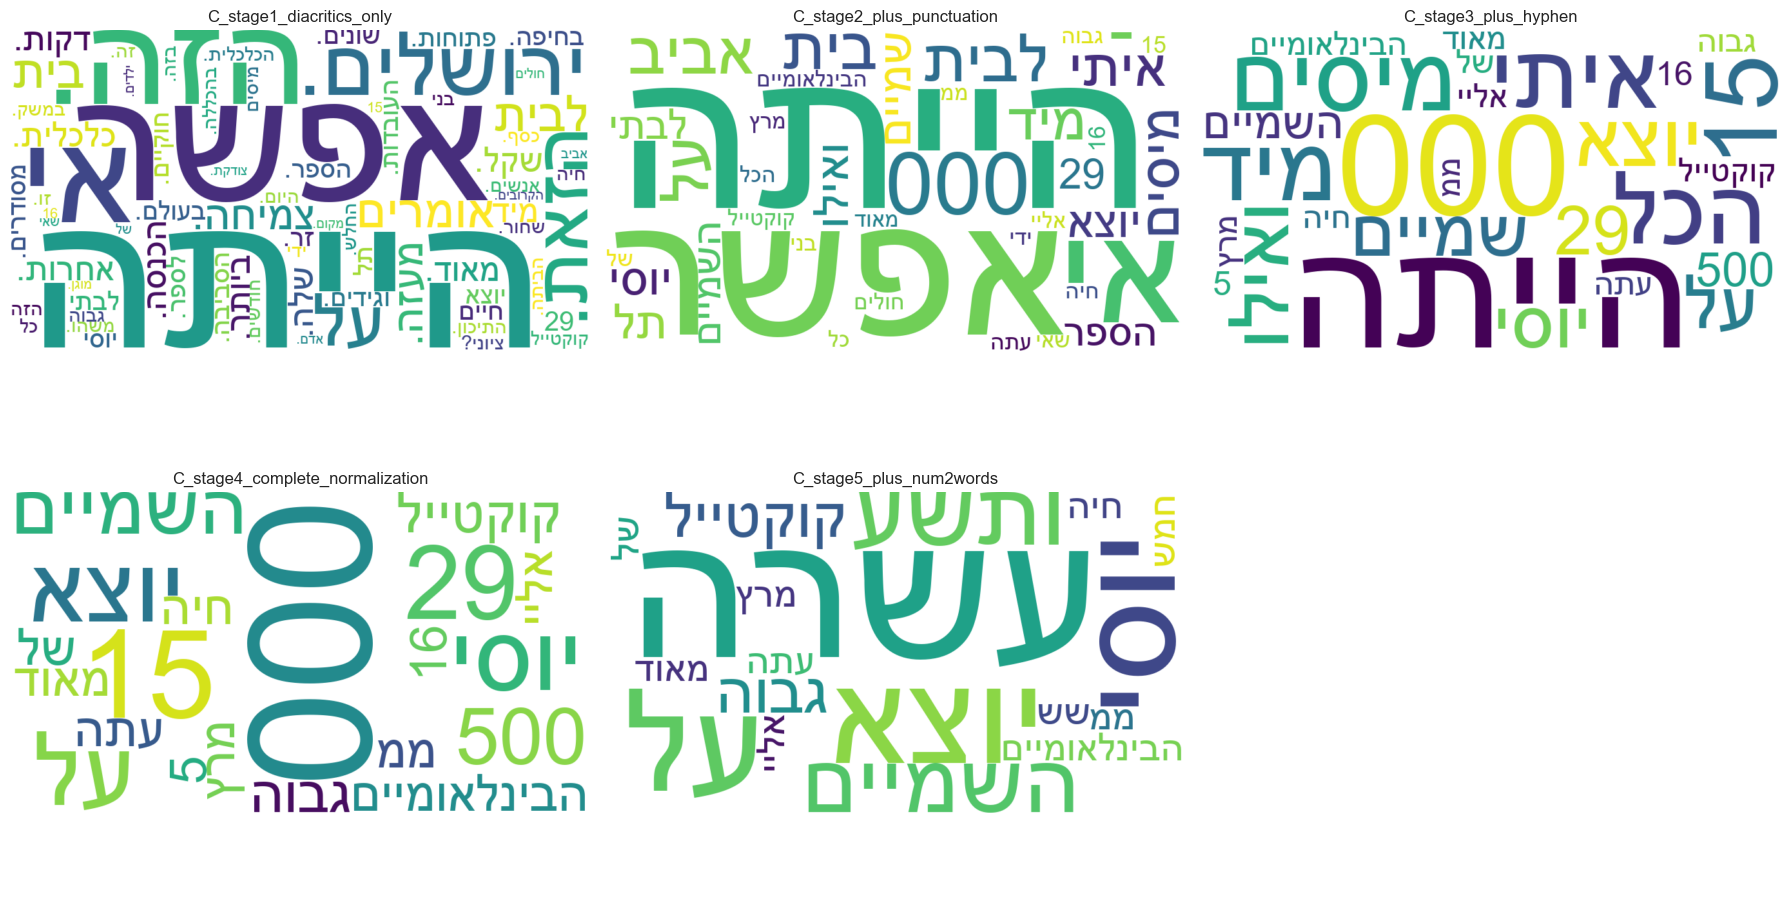

In [70]:
# ===== Part C: word clouds of most frequent HypWord errors =====
import re
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from wordcloud import WordCloud
except ImportError as exc:
    raise ImportError("Install wordcloud to render this section: pip install wordcloud") from exc

# Optional: improves RTL rendering when available.
try:
    from bidi.algorithm import get_display
except ImportError:
    get_display = None

font_candidates = [
    Path(r"C:/Windows/Fonts/arial.ttf"),
    Path(r"C:/Windows/Fonts/David.ttf"),
    Path(r"/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"),
]
font_path = next((str(p) for p in font_candidates if p.exists()), None)

HEBREW_RE = re.compile(r"[\u0590-\u05FF]")

def format_hypword_for_cloud(hyp_word: str) -> str:
    token = str(hyp_word).strip()
    if token == "" or token.lower() == "nan":
        return ""

    if HEBREW_RE.search(token):
        if get_display is not None:
            token = get_display(token)
        else:
            # Fallback when python-bidi is unavailable.
            token = token[::-1]
    return token

def build_hypword_frequencies(df: pd.DataFrame) -> dict[str, float]:
    freqs: dict[str, float] = {}
    for _, row in df.iterrows():
        hyp_word = format_hypword_for_cloud(row.get("HypWord", ""))
        count = float(row.get("Count", 0) or 0)
        if count <= 0 or hyp_word == "":
            continue
        freqs[hyp_word] = freqs.get(hyp_word, 0.0) + count
    return freqs

num_stages = len(stage_error_dfs)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax_idx, (stage_name, err_df) in enumerate(stage_error_dfs.items()):
    ax = axes[ax_idx]
    freqs = build_hypword_frequencies(err_df)
    if not freqs:
        ax.text(0.5, 0.5, "No HypWord data", ha="center", va="center", fontsize=12)
        ax.set_title(stage_name)
        ax.axis("off")
        continue

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        collocations=False,
        font_path=font_path,
    ).generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(stage_name)
    ax.axis("off")

for i in range(num_stages, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()
